<a href="https://colab.research.google.com/github/maibamrakeshsingh/Synthetic-Data-Generation-Integrating-Probabilistic-Models-Copulas-and-Large-Language-Models/blob/main/Synthetic_Data_Generation_Integrating_Probabilistic_Models%2C_Copulas%2C_and_Large_Language_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Data Generation Integrating Probabilistic Models, Copulas, and Large Language Models

The rapid growth of machine learning and data-driven decision-making has created an increasing demand for high-quality datasets. However, in domains such as healthcare, finance, and social sciences, strict privacy regulations often limit access to real-world data, posing significant challenges for model development, testing, and research. Synthetic data generation offers a promising solution by producing artificial datasets that preserve the statistical characteristics of real data while protecting sensitive information.

This project presents a comprehensive framework for synthetic data generation that combines probabilistic modeling, copula-based dependency structures, and Large Language Models (LLMs). The proposed approach aims to generate realistic and privacy-preserving datasets that accurately capture complex relationships, distributions, and patterns observed in real-world data without revealing any actual individual records.

The framework incorporates multiple data generation methodologies, including statistical sampling techniques for modeling marginal distributions, copula models for capturing multivariate dependencies, and LLM-based approaches for generating structured and contextually consistent synthetic observations. Furthermore, a rigorous validation process is employed to evaluate statistical fidelity, data utility, and privacy preservation.

Using a healthcare analytics application as a case study, the project demonstrates how synthetic datasets can effectively support machine learning workflows, data sharing, and research activities while ensuring compliance with privacy and regulatory requirements. By integrating classical statistical methods with modern generative AI techniques, the proposed framework provides a robust and scalable solution for generating high-fidelity synthetic data in privacy-sensitive environments.


## Objectives of the Project

Upon completion of this project, the following objectives will be achieved:

* Develop a comprehensive synthetic data generation pipeline using modern artificial intelligence and statistical techniques.
* Utilize Large Language Models (LLMs) to generate realistic textual and structured synthetic data.
* Implement probabilistic sampling methods and copula-based models to preserve marginal distributions and dependency structures within the data.
* Generate high-quality synthetic datasets that closely resemble the statistical properties of real-world datasets while ensuring privacy protection.
* Design and apply validation frameworks to evaluate the quality, utility, and privacy-preserving characteristics of synthetic data.
* Demonstrate the application of synthetic data generation techniques in privacy-sensitive domains such as healthcare analytics.


## Tools and Technologies Used

The implementation of the synthetic data generation framework relies on several Python libraries that support data generation, statistical modeling, machine learning, and data analysis. The key libraries utilized in this project are:

* **LangChain** – Used for orchestrating Large Language Model (LLM)-based synthetic data generation workflows.
* **LangChain-OpenAI** – Provides access to advanced GPT models for generating realistic textual and structured synthetic data.
* **Faker** – Generates realistic synthetic records, including names, addresses, dates, and other demographic information.
* **SDV (Synthetic Data Vault)** – Supports advanced synthetic data generation through statistical and machine learning-based modeling techniques.
* **Pandas** – Facilitates data manipulation, preprocessing, and exploratory data analysis.
* **NumPy** – Provides efficient numerical computation and probabilistic sampling capabilities.
* **SciPy** – Offers advanced statistical distributions and analytical functions for probabilistic modeling and synthetic data generation.

These tools collectively enable the development of a robust framework for generating realistic, statistically consistent, and privacy-preserving synthetic datasets.


**Installing Required Libraries**

In [ ]:
%%capture
!pip install langchain-openai==0.3.30  | tail -n 1
!pip install langchain==0.3.27 | tail -n 1
!pip install langchain-core==0.3.74 | tail -n 1
!pip install openai==1.99.9 | tail -n 1
!pip install pandas==2.3.1 | tail -n 1
!pip install numpy==2.3.2 | tail -n 1
!pip install matplotlib==3.10.5 | tail -n 1
!pip install seaborn==0.13.2 | tail -n 1
!pip install scikit-learn==1.7.1 | tail -n 1
!pip install sdv==1.18.0 | tail -n 1
!pip install scipy==1.15.2 | tail -n 1
!pip install -U numpy scipy
!pip install --upgrade scipy
!pip install numpy==1.26.4
!pip uninstall numpy scipy -y
!pip install numpy==2.0.0 scipy==1.14.0

**Libraries**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import json
from typing import List, Dict, Any, Optional
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from faker import Faker
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

from langchain_openai import OpenAI, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain.chat_models import init_chat_model

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**Key Terminology**

Before proceeding with the implementation, it is important to understand the fundamental concepts that form the basis of this project. The following terms provide essential background knowledge for synthetic data generation and privacy-preserving analytics.

| Term                     | Definition                                                                                                                                                                                                           |
| ------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Synthetic Data**       | Artificially generated data designed to replicate the statistical characteristics, patterns, and relationships of real-world data without containing any actual observations or personally identifiable information. |
| **LLM-Based Generation** | A synthetic data generation approach that utilizes Large Language Models (LLMs) to learn patterns from existing data and generate realistic, contextually consistent synthetic records.                              |
| **Statistical Sampling** | A methodology that employs probability distributions and statistical techniques to generate synthetic observations while preserving the underlying mathematical properties of the original dataset.                  |
| **Copula Methods**       | Statistical modeling techniques that capture and reproduce dependency structures among multiple variables independently of their marginal distributions, enabling realistic multivariate data generation.            |
| **Privacy Preservation** | The process of ensuring that synthetic datasets do not disclose sensitive information or allow the reconstruction of individual records from the original dataset, thereby safeguarding data confidentiality.        |


**Overview of Synthetic Data Generation**

Synthetic data generation has emerged as a powerful approach in modern data science, enabling organizations to overcome challenges related to data privacy, accessibility, and scalability. By creating artificial datasets that preserve the statistical characteristics of real-world data, synthetic data supports a wide range of analytical and machine learning applications while protecting sensitive information.

The importance of synthetic data generation can be observed across several key areas:

* **Privacy Preservation:** Enables the creation of datasets that retain analytical value without exposing confidential or personally identifiable information.
* **Data Augmentation:** Enhances limited datasets by generating additional observations, thereby improving the robustness and performance of machine learning models.
* **Testing and Development:** Provides realistic datasets for software testing, model validation, and quality assurance without relying on sensitive production data.
* **Bias Reduction:** Facilitates the generation of balanced datasets that help address representation gaps and improve fairness in predictive models.
* **Regulatory Compliance:** Supports data sharing, collaboration, and research activities while adhering to privacy regulations and governance requirements.

In this project, a comprehensive synthetic data generation framework is developed by integrating probabilistic modeling, statistical sampling techniques, copula-based dependency modeling, and Large Language Models (LLMs). The objective is to generate realistic, high-quality, and privacy-preserving synthetic datasets that accurately capture the underlying structure and relationships present in real-world data.


**Modern Approaches to Synthetic Data Generation**

Recent advances in synthetic data generation have introduced a variety of techniques that combine statistical modeling with artificial intelligence to create realistic and privacy-preserving datasets. Each approach offers unique advantages depending on the nature of the data and the intended application.

The principal methodologies employed in modern synthetic data generation include:

* **Statistical Methods:** Utilize probability distributions, sampling techniques, and copula-based models to reproduce the statistical characteristics and dependency structures present in real-world data.
* **LLM-Based Generation:** Employ Large Language Models (LLMs) to generate realistic textual content and structured data by learning contextual patterns and relationships from existing datasets.
* **GAN-Based Approaches:** Leverage Generative Adversarial Networks (GANs) to synthesize complex, high-dimensional data that closely resembles real observations.
* **Hybrid Techniques:** Integrate multiple generation methods to capitalize on the strengths of both statistical and AI-driven approaches, resulting in improved realism and data quality.
* **Conditional Data Generation:** Produce synthetic records that satisfy predefined constraints, dependencies, and domain-specific requirements, ensuring consistency and practical applicability.

Collectively, these approaches provide a flexible framework for generating diverse synthetic datasets while maintaining statistical fidelity, realism, and privacy protection.

**Implementation Strategy**

The synthetic data generation framework developed in this project follows a structured implementation strategy designed to ensure both data quality and privacy preservation. The key stages include:

1. **Development of Statistical Generators**

   * Implement probabilistic sampling techniques and copula-based models to preserve marginal distributions and multivariate dependencies.

2. **Construction of LLM-Based Generators**

   * Utilize Large Language Models to generate realistic textual and structured synthetic data that reflects patterns observed in real datasets.

3. **Validation and Quality Assessment**

   * Design comprehensive evaluation metrics to assess statistical similarity, data utility, realism, and privacy preservation.

4. **Framework Integration**

   * Combine statistical, copula-based, and LLM-driven approaches into a unified synthetic data generation pipeline capable of producing high-quality synthetic datasets for analytical and machine learning applications.

This integrated strategy enables the creation of realistic, statistically consistent, and privacy-aware synthetic data suitable for research, testing, model development, and data-sharing scenarios.

**Building the Synthetic Data Generation Framework**

Configuring the Large Language Model (LLM)

A key component of the proposed synthetic data generation framework is the use of a Large Language Model (LLM) to generate realistic and contextually consistent synthetic records. For this project, the OpenAI **GPT-5 Mini** model is employed due to its ability to understand complex data patterns and generate high-quality synthetic content.

The computational environment provides limited access to the model for experimentation and development purposes. Users who exceed the allocated usage quota may need to wait for the quota to reset before continuing.

The model is configured using the following parameters:

| Parameter          | Type    | Value      | Description                                                                                                      |
| ------------------ | ------- | ---------- | ---------------------------------------------------------------------------------------------------------------- |
| **Model Name**     | String  | GPT-5 Mini | The OpenAI model used for synthetic data generation and contextual understanding.                                |
| **Temperature**    | Float   | 0.7        | Controls the randomness and diversity of generated outputs; higher values produce more varied synthetic records. |
| **Maximum Tokens** | Integer | 2000       | Specifies the maximum length of the generated response.                                                          |

For synthetic data generation, a temperature value of **0.7** is selected to balance realism and diversity. Unlike code generation tasks, which often require deterministic outputs, synthetic data generation benefits from increased variability to better capture the natural heterogeneity observed in real-world datasets. This configuration enables the model to generate diverse yet coherent synthetic observations while preserving the overall quality and consistency of the generated data.


**Temperature and Token Settings for Synthetic Data Generation**

Understanding Temperature

Temperature is an important parameter in Large Language Models (LLMs) that controls the level of randomness and diversity in generated outputs. In synthetic data generation, selecting an appropriate temperature helps create realistic and varied records while maintaining consistency.

**Temperature Ranges**

* **0.3 – 0.5 (Low Temperature):**
  Produces less diverse and more predictable outputs. Suitable for highly structured datasets with strict constraints.

* **0.6 – 0.8 (Moderate Temperature):**
  Generates a balanced level of diversity and realism. This range is generally recommended for creating high-quality synthetic datasets.

* **0.9 – 1.2 (High Temperature):**
  Produces highly diverse outputs and can be useful for generating rare cases, edge scenarios, or augmenting underrepresented data.

**Why Use a Moderate Temperature?**

Unlike code generation, where deterministic and precise outputs are preferred, synthetic data generation benefits from controlled randomness. Each synthetic record should be unique while remaining realistic and representative of real-world patterns.

For this project, a **temperature value of 0.7** is selected because it provides an effective balance between diversity and plausibility, resulting in realistic and varied synthetic observations.

**Example**

**Prompt:** Generate a patient medical history.

* **Temperature = 0.3:** Produces similar patient histories with common conditions.
* **Temperature = 0.7:** Generates diverse and realistic patient profiles with varying medical conditions.
* **Temperature = 1.2:** Produces highly varied and occasionally unusual, yet plausible, medical scenarios.

**Summary**

* **Low Temperature:** Less diversity; may not fully capture real-world variability.
* **Moderate Temperature (0.7):** Balanced, realistic, and diverse synthetic data generation.
* **High Temperature:** Maximum diversity; useful for generating rare or edge-case scenarios.

---

**Token Limits for Batch Generation**

The **max_tokens** parameter determines the maximum length of the model's output. When generating multiple synthetic records in a single request, sufficient token allocation is necessary to ensure complete results.

**Token Requirements**

* **Single Synthetic Record:** Approximately 200–500 tokens.
* **Batch of 10 Records:** Approximately 2,000–3,000 tokens.
* **Complex Multi-Field Records:** May require 5,000 or more tokens.

**Example**

For the prompt:

*"Generate five synthetic patient records containing demographics, medical history, and diagnoses."*

* With **max_tokens = 2000**, the model can typically generate all five records.
* With **max_tokens = 500**, the output may be truncated before all records are completed.

For this project, **max_tokens = 2000** is used to support efficient batch generation while maintaining computational efficiency.

---

**Recommended Configuration**

To generate realistic and complete synthetic datasets, the following configuration is recommended:

* **Temperature = 0.7**
* **Max Tokens = 2000**

This combination provides a practical balance between diversity, realism, output completeness, and computational cost, making it well-suited for synthetic data generation tasks.


**API Usage**

This project uses Large Language Models (LLMs) provided by OpenAI. Within the Skills Network environment, access to these models is pre-configured, allowing users to experiment with LLM-based synthetic data generation without providing their own API keys, subject to usage limitations.

If you wish to run this project in a local environment outside Skills Network, you will need to obtain and configure your own OpenAI API key. Please note that using a personal API key may result in usage charges based on OpenAI's pricing policies.


In [ ]:
from langchain_core.language_models.llms import LLM
from typing import Optional, List, Mapping, Any

class MockLLM(LLM):
    """A mock LLM that returns a placeholder response."""

    @property
    def _llm_type(self) -> str:
        return "mock"

    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        # Return a dummy JSON structure that your downstream code expects
        return '{"response": "This is a mock response from the free Skills Network environment."}'

    @property
    def _identifying_params(self) -> Mapping[str, Any]:
        return {"model": "mock"}

llm = MockLLM()

**Creating Statistical Samplers**

Statistical sampling is a key component of synthetic data generation, allowing artificial data to preserve the statistical properties of real datasets. The `StatisticalSampler` class is initialized with a fixed random seed to ensure reproducibility and uses both NumPy and Faker for generating numerical and realistic synthetic data. The `sample_numerical()` method generates samples from different probability distributions, such as normal, uniform, and exponential distributions, by accepting distribution-specific parameters. For example, when a normal distribution is selected, the method uses the specified mean and standard deviation values, or defaults to a standard normal distribution if no parameters are provided.


In [ ]:
class StatisticalSampler:
    """
    Statistical sampling for numerical and categorical data generation.
    """
    def __init__(self, seed: Optional[int] = 42):
        self.rng = np.random.RandomState(seed)
        self.faker = Faker()
        Faker.seed(seed)

    def sample_numerical(self, distribution: str, size: int, **params) -> np.ndarray:
        """
        Sample from various numerical distributions.

        Args:
            distribution (str): Type of distribution ('normal', 'uniform', 'exponential', 'beta', 'gamma')
            size (int): Number of samples to generate
            **params: Distribution-specific parameters

        Returns:
            np.ndarray: Array of sampled values
        """
        if distribution == "normal":
            return self.rng.normal(params.get('mean', 0), params.get('std', 1), size)
        elif distribution == "uniform":
            return self.rng.uniform(params.get('low', 0), params.get('high', 1), size)
        elif distribution == "exponential":
            return self.rng.exponential(params.get('scale', 1), size)
        elif distribution == "beta":
            return self.rng.beta(params.get('a', 2), params.get('b', 5), size)
        elif distribution == "gamma":
            return self.rng.gamma(params.get('shape', 2), params.get('scale', 1), size)
        else:
            raise ValueError(f"Unknown distribution: {distribution}")

    def sample_categorical(self, categories: List[str], size: int,
                          probabilities: Optional[List[float]] = None) -> np.ndarray:
        """
        Sample categorical data with optional probability weights.

        Args:
            categories (List[str]): List of category values
            size (int): Number of samples
            probabilities (Optional[List[float]]): Probability for each category

        Returns:
            np.ndarray: Array of sampled categories
        """
        if probabilities is not None:
            probabilities = np.array(probabilities) / np.sum(probabilities)
        return self.rng.choice(categories, size=size, p=probabilities)

    def sample_correlated(self, mean: np.ndarray, cov: np.ndarray, size: int) -> np.ndarray:
        """
        Sample from multivariate normal distribution to create correlated features.

        Args:
            mean (np.ndarray): Mean vector for each variable
            cov (np.ndarray): Covariance matrix
            size (int): Number of samples

        Returns:
            np.ndarray: Array of correlated samples
        """
        return self.rng.multivariate_normal(mean, cov, size)

**Understanding Correlated Sampling**

In real-world datasets, variables are often related rather than independent. For example, in healthcare data, age and blood pressure typically show a positive correlation, with older individuals tending to have higher blood pressure. To preserve such relationships in synthetic datasets, correlated sampling is performed using a multivariate normal distribution. This approach utilizes a mean vector to represent the average values of variables and a covariance matrix to capture their variances and dependencies. By sampling from this distribution, the generated synthetic data maintains realistic correlations between features, resulting in more accurate and representative datasets.


**Building LLM-Based Data Generators**

While statistical methods are effective for generating numerical data, Large Language Models (LLMs) are particularly well suited for creating realistic text and complex structured records. The `LLMDataGenerator` class is designed to leverage the capabilities of an LLM for synthetic data generation while ensuring that the output is returned in a structured JSON format. A JSON parser is included to convert the model's responses into data that can be easily integrated into datasets and analytical workflows.

To guide the generation process, a prompt template is created using system and user messages. The system message instructs the model to act as an expert synthetic data generator, emphasizing realism, diversity, and consistency in the generated records. This guidance helps improve the quality and reliability of the synthetic data.

The generation workflow is implemented through a LangChain pipeline, where user input is first processed by the prompt template, then passed to the LLM, and finally parsed into structured JSON output. This modular approach simplifies the data generation process and improves maintainability.

One of the key advantages of LLM-based generation is its flexibility. Unlike traditional statistical methods that require predefined distributions and parameters, LLMs can generate realistic synthetic records directly from natural language descriptions. Whether generating patient records, customer profiles, or product reviews, the model can create diverse and contextually meaningful data with minimal manual configuration.


In [ ]:
class LLMDataGenerator:
    """
    LLM-based synthetic data generator for text and structured data.
    """
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()

    def generate_records(self, schema: Dict[str, Any], num_records: int,
                        context: Optional[str] = None) -> List[Dict[str, Any]]:
        """
        Generate synthetic records following a specified schema.

        Args:
            schema (Dict[str, Any]): Field definitions and types
            num_records (int): Number of records to generate
            context (Optional[str]): Additional context for generation

        Returns:
            List[Dict[str, Any]]: List of generated synthetic records
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "You are an expert at generating realistic synthetic data. "
                      "Generate diverse, realistic records that follow the provided schema. "
                      "Ensure each record is unique and plausible. Return data as a JSON array."),
            ("user", "{input}")
        ])

        schema_desc = json.dumps(schema, indent=2)
        context_str = f"\nContext: {context}" if context else ""

        input_text = f"""Generate {num_records} synthetic records following this schema:
{schema_desc}{context_str}

Return ONLY a JSON array of records, no additional text."""

        chain = prompt | self.llm | self.parser

        try:
            result = chain.invoke({"input": input_text})
            return result if isinstance(result, list) else [result]
        except Exception as e:
            print(f"Error generating records: {e}")
            return []

    def generate_text_field(self, field_description: str, num_samples: int) -> List[str]:
        """
        Generate synthetic text for a specific field.

        Args:
            field_description (str): Description of what to generate
            num_samples (int): Number of samples

        Returns:
            List[str]: List of generated text samples
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Generate realistic, diverse text samples. Return as a JSON array of strings."),
            ("user", "Generate {num} examples of: {description}")
        ])

        chain = prompt | self.llm | self.parser

        try:
            result = chain.invoke({"num": num_samples, "description": field_description})
            return result if isinstance(result, list) else []
        except Exception as e:
            print(f"Error generating text: {e}")
            return []

**Implementing Conditional Generation**

In many real-world datasets, certain variables depend on the values of other variables. For example, a patient's diagnosis should be consistent with their age, symptoms, and medical history. Conditional generation helps maintain these logical relationships, ensuring that synthetic data remains realistic and meaningful.

The `ConditionalGenerator` class enhances the data generation process by allowing specific conditions and constraints to be applied when generating a target field. The method takes an existing record, the field to be generated, and a set of conditions that guide the generation process.

A major advantage of this approach is the ability of Large Language Models (LLMs) to understand context and relationships between variables. For instance, if a patient is elderly and presents symptoms such as chest pain and shortness of breath, the model can generate an appropriate diagnosis that aligns with these characteristics. This semantic understanding enables the creation of synthetic datasets that are both realistic and logically consistent, closely reflecting real-world scenarios.


In [ ]:
class ConditionalGenerator:
    """
    Generate synthetic data with conditional dependencies.
    """
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()

    def generate_conditional(self, base_record: Dict[str, Any],
                           target_field: str, conditions: Dict[str, Any]) -> Any:
        """
        Generate a field value conditioned on other fields.

        Args:
            base_record (Dict[str, Any]): Existing record fields
            target_field (str): Field to generate
            conditions (Dict[str, Any]): Conditional constraints

        Returns:
            Any: Generated field value
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Generate realistic field values that are consistent with given conditions."),
            ("user", """Given this record: {record}

Generate a realistic value for the field '{field}' that satisfies these conditions:
{conditions}

Return only the value, properly formatted for the field type.""")
        ])

        chain = prompt | self.llm | StrOutputParser()

        try:
            result = chain.invoke({
                "record": json.dumps(base_record),
                "field": target_field,
                "conditions": json.dumps(conditions)
            })
            return result.strip()
        except Exception as e:
            print(f"Error in conditional generation: {e}")
            return None

**Data Validation and Quality Assessment**

Generating synthetic data is valuable only when the resulting data is realistic, statistically reliable, and privacy-preserving. Therefore, a comprehensive validation framework is essential to assess the quality of synthetic datasets and ensure they are suitable for analysis and machine learning applications.

The `DataValidator` class evaluates the statistical similarity between real and synthetic datasets by comparing key characteristics such as data distributions, variable relationships, and value ranges. One commonly used measure is the Kolmogorov–Smirnov (K-S) test, which determines whether the distributions of real and synthetic data are statistically similar. A higher p-value generally indicates greater similarity between the two distributions.

In addition to statistical validation, privacy assessment is performed to ensure that synthetic records do not closely replicate actual records from the original dataset. This helps reduce the risk of re-identification and protects sensitive information. Effective synthetic data should preserve overall statistical patterns while remaining distinct at the individual record level.

Together, these validation and privacy metrics provide confidence in the quality, utility, and safety of the generated synthetic datasets, enabling their use in research, testing, and machine learning development.


In [ ]:
class DataValidator:
    """
    Validate synthetic data quality and privacy preservation.
    """
    @staticmethod
    def validate_statistical_similarity(real_data: pd.DataFrame,
                                       synthetic_data: pd.DataFrame) -> Dict[str, Any]:
        """
        Validate that synthetic data has similar statistical properties to real data.

        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Generated synthetic dataset

        Returns:
            Dict[str, Any]: Validation metrics and results
        """
        results = {}

        # Compare numerical columns
        numerical_cols = real_data.select_dtypes(include=[np.number]).columns

        for col in numerical_cols:
            # Kolmogorov-Smirnov test for distribution similarity
            ks_stat, p_value = stats.ks_2samp(real_data[col], synthetic_data[col])

            results[col] = {
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'similar': p_value > 0.05,  # Not significantly different
                'real_mean': real_data[col].mean(),
                'synthetic_mean': synthetic_data[col].mean(),
                'real_std': real_data[col].std(),
                'synthetic_std': synthetic_data[col].std()
            }

        return results

    @staticmethod
    def check_privacy(real_data: pd.DataFrame,
                     synthetic_data: pd.DataFrame) -> Dict[str, Any]:
        """
        Check privacy preservation - ensure synthetic records are not too similar to real ones.

        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset

        Returns:
            Dict[str, Any]: Privacy metrics
        """
        # Normalize numerical columns
        numerical_cols = real_data.select_dtypes(include=[np.number]).columns

        if len(numerical_cols) == 0:
            return {"status": "No numerical columns to check"}

        scaler = StandardScaler()
        real_scaled = scaler.fit_transform(real_data[numerical_cols])
        synthetic_scaled = scaler.transform(synthetic_data[numerical_cols])

        # Calculate minimum distance from each synthetic record to any real record
        min_distances = []
        for syn_record in synthetic_scaled[:100]:  # Sample for efficiency
            distances = np.linalg.norm(real_scaled - syn_record, axis=1)
            min_distances.append(np.min(distances))

        return {
            'mean_min_distance': np.mean(min_distances),
            'std_min_distance': np.std(min_distances),
            'privacy_risk': 'HIGH' if np.mean(min_distances) < 0.1 else
                           'MEDIUM' if np.mean(min_distances) < 0.5 else 'LOW'
        }

    @staticmethod
    def visualize_comparison(real_data: pd.DataFrame,
                           synthetic_data: pd.DataFrame,
                           columns: Optional[List[str]] = None):
        """
        Create visualization comparing real and synthetic data distributions.

        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to visualize
        """
        if columns is None:
            columns = real_data.select_dtypes(include=[np.number]).columns[:4]

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()

        for idx, col in enumerate(columns[:4]):
            if col in real_data.columns and col in synthetic_data.columns:
                axes[idx].hist(real_data[col], alpha=0.5, label='Real', bins=30)
                axes[idx].hist(synthetic_data[col], alpha=0.5, label='Synthetic', bins=30)
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')
                axes[idx].legend()
                axes[idx].set_title(f'Distribution: {col}')

        plt.tight_layout()
        plt.show()

**Complete Pipeline Integration**

To streamline the synthetic data generation process, all components are integrated into a unified framework through the `SyntheticDataPipeline` class. This pipeline combines statistical sampling, LLM-based generation, conditional generation, and data validation into a single system, enabling the creation of realistic and privacy-preserving synthetic datasets.

The `generate_dataset()` method supports three generation strategies: **statistical**, **LLM-based**, and **hybrid**. The statistical approach is efficient for generating numerical data with predefined distributions, while the LLM-based approach excels at producing realistic textual and structured data. The hybrid approach combines the strengths of both methods, using statistical techniques for numerical variables and LLMs for textual or categorical attributes.

In practice, the hybrid method often provides the best balance between statistical accuracy and data realism. By integrating multiple generation techniques within a single pipeline, the framework can efficiently produce diverse, high-quality synthetic datasets suitable for machine learning, testing, and research applications.


In [ ]:
class SyntheticDataPipeline:
    """
    Complete pipeline for synthetic data generation combining multiple methods.
    """
    def __init__(self, llm, seed: int = 42):
        self.statistical_sampler = StatisticalSampler(seed)
        self.llm_generator = LLMDataGenerator(llm)
        self.conditional_generator = ConditionalGenerator(llm)
        self.validator = DataValidator()
        self.faker = Faker()
        Faker.seed(seed)

    def generate_dataset(self, schema: Dict[str, Any], num_records: int,
                        method: str = 'hybrid') -> pd.DataFrame:
        """
        Generate a complete synthetic dataset.

        Args:
            schema (Dict[str, Any]): Dataset schema definition
            num_records (int): Number of records to generate
            method (str): Generation method ('statistical', 'llm', 'hybrid')

        Returns:
            pd.DataFrame: Generated synthetic dataset
        """
        if method == 'llm':
            records = self.llm_generator.generate_records(schema, num_records)
            return pd.DataFrame(records)

        elif method == 'statistical':
            return self._generate_statistical(schema, num_records)

        elif method == 'hybrid':
            return self._generate_hybrid(schema, num_records)

        else:
            raise ValueError(f"Unknown method: {method}")

    def _generate_statistical(self, schema: Dict[str, Any], num_records: int) -> pd.DataFrame:
        """Generate dataset using statistical methods."""
        data = {}

        for field, config in schema.items():
            field_type = config.get('type', 'numerical')

            if field_type == 'numerical':
                distribution = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = self.statistical_sampler.sample_numerical(
                    distribution, num_records, **params
                )

            elif field_type == 'categorical':
                categories = config.get('categories', [])
                probabilities = config.get('probabilities', None)
                data[field] = self.statistical_sampler.sample_categorical(
                    categories, num_records, probabilities
                )

        return pd.DataFrame(data)

    def _generate_hybrid(self, schema: Dict[str, Any], num_records: int) -> pd.DataFrame:
        """Generate dataset using hybrid approach."""
        # Start with statistical generation for numerical fields
        data = {}

        # Generate numerical and simple categorical fields statistically
        for field, config in schema.items():
            field_type = config.get('type', 'numerical')

            if field_type == 'numerical':
                distribution = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = self.statistical_sampler.sample_numerical(
                    distribution, num_records, **params
                )

            elif field_type == 'categorical' and 'categories' in config:
                categories = config.get('categories', [])
                probabilities = config.get('probabilities', None)
                data[field] = self.statistical_sampler.sample_categorical(
                    categories, num_records, probabilities
                )

        df = pd.DataFrame(data)

        # Use LLM for text fields and complex categorical
        for field, config in schema.items():
            if config.get('type') == 'text' or (config.get('type') == 'categorical' and 'categories' not in config):
                description = config.get('description', f'Generate {field}')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                if len(text_samples) == num_records:
                    df[field] = text_samples

        return df

**Testing the Synthetic Data Generator**

To evaluate the effectiveness of the proposed framework, a synthetic healthcare dataset is generated containing patient demographics, vital signs, and medical information. A schema is first defined to specify the characteristics of each field, including data type, probability distribution, and associated parameters. For example, patient age is modeled using a normal distribution with a mean of 55 years and a standard deviation of 15 years, while blood pressure values are generated according to clinically realistic distributions.

In addition to numerical attributes, textual fields such as medical histories and chief complaints are generated using Large Language Models (LLMs). Descriptive prompts guide the model to produce realistic and contextually relevant healthcare-related content.

Using the integrated pipeline, synthetic patient records are generated through the hybrid approach, which combines statistical sampling for numerical variables with LLM-based generation for textual information. This approach produces a high-quality synthetic dataset that preserves the statistical properties and patterns of real healthcare data while ensuring that no actual patient information is disclosed, thereby maintaining privacy and regulatory compliance.


In [ ]:
# Initialize the pipeline
pipeline = SyntheticDataPipeline(llm)

# Define a healthcare dataset schema
patient_schema = {
    'age': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 55, 'std': 15}
    },
    'blood_pressure_systolic': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 125, 'std': 15}
    },
    'blood_pressure_diastolic': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 80, 'std': 10}
    },
    'bmi': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 26.5, 'std': 4.5}
    },
    'gender': {
        'type': 'categorical',
        'categories': ['Male', 'Female', 'Other'],
        'probabilities': [0.48, 0.48, 0.04]
    },
    'smoking_status': {
        'type': 'categorical',
        'categories': ['Never', 'Former', 'Current'],
        'probabilities': [0.6, 0.25, 0.15]
    },
    'chief_complaint': {
        'type': 'text',
        'description': 'realistic patient chief complaints for a general medicine clinic, 1-2 sentences'
    }
}

# Generate synthetic dataset
print("Generating synthetic patient dataset...")
synthetic_df = pipeline.generate_dataset(patient_schema, num_records=100, method='hybrid')

print(f"\nGenerated {len(synthetic_df)} synthetic patient records")
print("\nFirst 5 records:")
print(synthetic_df.head())

print("\nDataset statistics:")
print(synthetic_df.describe())

Generating synthetic patient dataset...

Generated 100 synthetic patient records

First 5 records:
         age  blood_pressure_systolic  blood_pressure_diastolic        bmi  \
0  62.450712               103.769439                 83.577874  22.769522   
1  52.926035               118.690320                 85.607845  23.979185   
2  64.715328               119.859282                 90.830512  29.862821   
3  77.845448               112.965841                 90.538021  29.246666   
4  51.487699               122.580714                 66.223306  26.405943   

   gender smoking_status  
0    Male          Never  
1    Male         Former  
2    Male          Never  
3  Female          Never  
4  Female         Former  

Dataset statistics:
              age  blood_pressure_systolic  blood_pressure_diastolic  \
count  100.000000               100.000000                100.000000   
mean    53.442302               125.334569                 80.648963   
std     13.622526                

**Advanced Usage: Copula-Based Synthetic Data Generation with Synthetic Data Vault (SDV)**

To generate highly realistic synthetic datasets, this project utilizes the **Synthetic Data Vault (SDV)** library and its **Gaussian Copula Synthesizer**. Copula-based methods are particularly effective because they model the dependency structure between variables separately from their individual distributions, allowing complex multivariate relationships to be preserved.

The process begins by creating metadata from an existing dataset using SDV's automatic schema detection capabilities. This metadata identifies column types and dataset characteristics, enabling the synthesizer to learn the underlying structure of the data. Once the metadata is prepared, the `GaussianCopulaSynthesizer` is trained on the dataset to capture both the marginal distributions of individual variables and the dependencies among them.

The Gaussian Copula approach operates through a two-stage transformation process. During model fitting, each variable is transformed into a standard normal representation, and a covariance matrix is estimated to capture the relationships among variables. During data generation, new samples are drawn from the learned multivariate normal distribution and transformed back to the original data scale. This process ensures that synthetic records preserve both the individual characteristics of each variable and the complex dependency patterns observed in the original dataset.

As a result, copula-based generation produces statistically consistent and realistic synthetic data, making it particularly valuable for applications that require accurate representation of multivariate relationships while maintaining data privacy.


In [ ]:
# Demonstrate SDV Gaussian Copula approach
def generate_with_sdv(sample_df: pd.DataFrame, num_records: int) -> pd.DataFrame:
    """
    Generate synthetic data using SDV's Gaussian Copula method.

    Args:
        sample_df (pd.DataFrame): Sample data to learn from
        num_records (int): Number of synthetic records to generate

    Returns:
        pd.DataFrame: Synthetic dataset
    """
    # Create metadata
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(sample_df)

    # Initialize and fit synthesizer
    synthesizer = GaussianCopulaSynthesizer(metadata)
    synthesizer.fit(sample_df)

    # Generate synthetic data
    synthetic_data = synthesizer.sample(num_records)

    return synthetic_data

# Example: Generate correlated patient data
# First create a small sample with correlations
np.random.seed(42)
sample_size = 50

# Create correlated features (age, blood pressure, BMI)
mean = [55, 125, 26.5]
cov = [[225, 50, 20],    # Age variance and covariances
       [50, 225, 15],     # BP variance and covariances
       [20, 15, 20.25]]   # BMI variance and covariances

correlated_data = np.random.multivariate_normal(mean, cov, sample_size)

sample_df = pd.DataFrame({
    'age': np.clip(correlated_data[:, 0], 18, 100),
    'blood_pressure_systolic': np.clip(correlated_data[:, 1], 90, 180),
    'bmi': np.clip(correlated_data[:, 2], 15, 45),
    'gender': np.random.choice(['Male', 'Female'], sample_size),
    'smoking_status': np.random.choice(['Never', 'Former', 'Current'], sample_size)
})

print("Sample data correlation matrix:")
print(sample_df[['age', 'blood_pressure_systolic', 'bmi']].corr())

# Generate synthetic data using SDV
print("\nGenerating synthetic data with SDV Gaussian Copula...")
sdv_synthetic = generate_with_sdv(sample_df, num_records=200)

print("\nSynthetic data correlation matrix:")
print(sdv_synthetic[['age', 'blood_pressure_systolic', 'bmi']].corr())

print("\nFirst 5 SDV-generated records:")
print(sdv_synthetic.head())

Sample data correlation matrix:
                              age  blood_pressure_systolic       bmi
age                      1.000000                -0.081185  0.312828
blood_pressure_systolic -0.081185                 1.000000  0.277256
bmi                      0.312828                 0.277256  1.000000

Generating synthetic data with SDV Gaussian Copula...

Synthetic data correlation matrix:
                              age  blood_pressure_systolic       bmi
age                      1.000000                -0.011193  0.326666
blood_pressure_systolic -0.011193                 1.000000  0.251168
bmi                      0.326666                 0.251168  1.000000

First 5 SDV-generated records:
         age  blood_pressure_systolic        bmi  gender smoking_status
0  70.600607               125.178109  32.605782    Male          Never
1  49.606775               125.498715  24.451151  Female         Former
2  78.913618               125.659705  32.000459  Female         Former
3  48

**Validating Synthetic Data Quality**

Evaluating the quality of synthetic data is a critical step to ensure that the generated datasets are both realistic and suitable for downstream applications. The `DataValidator` class provides a comprehensive framework for assessing statistical similarity and privacy preservation between real and synthetic datasets.

Statistical validation compares the distributions of numerical variables using measures such as the **Kolmogorov–Smirnov (K-S) test** and the **two-sample t-test**. The K-S statistic quantifies the difference between the distributions of real and synthetic data, with smaller values indicating greater similarity. The associated p-value helps determine whether the observed differences are statistically significant. Similarly, the two-sample t-test evaluates whether the means of the two datasets differ significantly, providing additional insight into data fidelity.

In addition to statistical accuracy, privacy protection is assessed by measuring the similarity between synthetic and real records. The validation process calculates the distance from each synthetic record to its closest real counterpart. Larger distances indicate stronger privacy preservation, as the synthetic data is less likely to replicate or reveal information about specific individuals.

A **low privacy risk** suggests that the synthetic dataset successfully balances privacy and utility, maintaining the overall statistical characteristics of the original data while ensuring that individual records cannot be easily identified or reconstructed.


Validating synthetic data quality...

Statistical Similarity Results:

age:
  Similar distribution: True
  KS statistic: 0.1950
  p-value: 0.0880
  Real mean: 54.54, Synthetic mean: 56.06
  Real std: 13.84, Synthetic std: 16.22

blood_pressure_systolic:
  Similar distribution: True
  KS statistic: 0.0850
  p-value: 0.9220
  Real mean: 126.61, Synthetic mean: 126.02
  Real std: 11.84, Synthetic std: 11.43

bmi:
  Similar distribution: True
  KS statistic: 0.0700
  p-value: 0.9856
  Real mean: 26.17, Synthetic mean: 25.95
  Real std: 4.85, Synthetic std: 4.94


Privacy Validation Results:
  Mean minimum distance to real records: 0.5922
  Privacy risk level: LOW

Generating comparison visualizations...


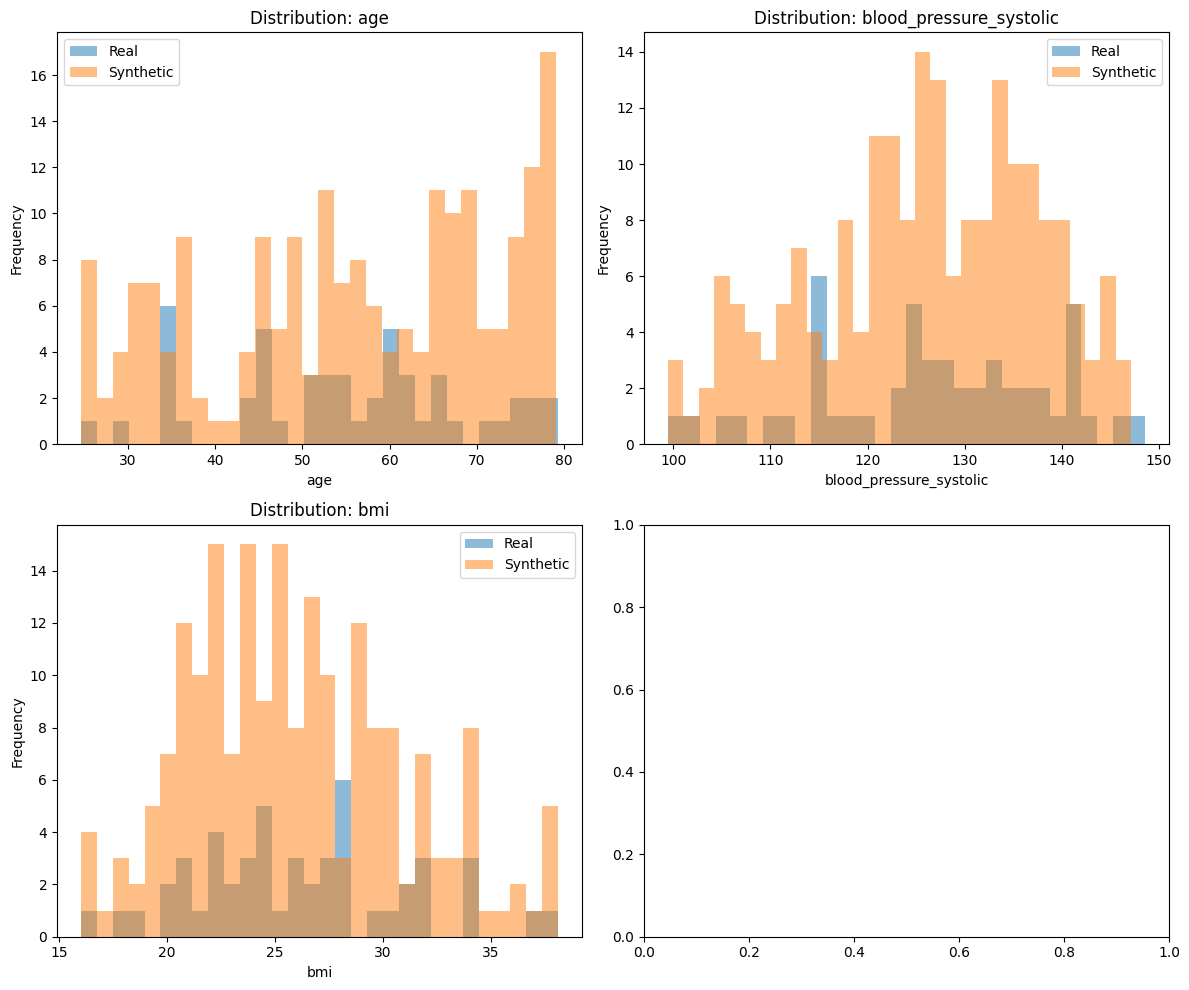

In [ ]:
# Validate the synthetic data
print("Validating synthetic data quality...\n")

validation_results = pipeline.validator.validate_statistical_similarity(
    sample_df, sdv_synthetic
)

print("Statistical Similarity Results:")
print("=" * 50)
for column, metrics in validation_results.items():
    print(f"\n{column}:")
    print(f"  Similar distribution: {metrics['similar']}")
    print(f"  KS statistic: {metrics['ks_statistic']:.4f}")
    print(f"  p-value: {metrics['p_value']:.4f}")
    print(f"  Real mean: {metrics['real_mean']:.2f}, Synthetic mean: {metrics['synthetic_mean']:.2f}")
    print(f"  Real std: {metrics['real_std']:.2f}, Synthetic std: {metrics['synthetic_std']:.2f}")

privacy_check = pipeline.validator.check_privacy(sample_df, sdv_synthetic)
print("\n" + "=" * 50)
print("\nPrivacy Validation Results:")
print(f"  Mean minimum distance to real records: {privacy_check['mean_min_distance']:.4f}")
print(f"  Privacy risk level: {privacy_check['privacy_risk']}")

# Visualize the comparison
print("\nGenerating comparison visualizations...")
pipeline.validator.visualize_comparison(
    sample_df, sdv_synthetic,
    columns=['age', 'blood_pressure_systolic', 'bmi']
)

**Multi-Modal Data Generation**

Real-world datasets often consist of multiple types of information, including numerical values, categorical attributes, textual content, and temporal data. Generating realistic synthetic datasets therefore requires a framework capable of handling these diverse data modalities while preserving their relationships and consistency.

In this task, the objective is to develop a **MultiModalGenerator** that can generate and integrate different types of synthetic data into a unified dataset. The target application involves creating synthetic e-commerce transaction records containing numerical features such as transaction amount, purchase quantity, and customer age; categorical attributes such as product category and payment method; textual information including product descriptions and customer reviews; and temporal data represented by transaction timestamps.

By combining these modalities within a single generation framework, the resulting synthetic dataset will more accurately reflect the complexity of real-world e-commerce data. Follow the provided TODO instructions to implement the methods required for generating each data type and integrating them into a cohesive and realistic synthetic dataset.


In [ ]:
class MultiModalGenerator:
    """
    Generate synthetic data across multiple modalities.
    """
    def __init__(self, llm, seed: int = 42):
        self.llm = llm
        self.faker = Faker()
        Faker.seed(seed)
        self.rng = np.random.RandomState(seed)
        self.llm_generator = LLMDataGenerator(llm)

    def generate_temporal_data(self, num_records: int,
                              start_date: datetime,
                              end_date: datetime) -> List[datetime]:
        """
        Generate synthetic timestamp data.

        Args:
            num_records (int): Number of timestamps to generate
            start_date (datetime): Start of date range
            end_date (datetime): End of date range

        Returns:
            List[datetime]: List of generated timestamps
        """
        # Calculate time delta
        time_delta = (end_date - start_date).total_seconds()

        # Generate random offsets
        offsets = self.rng.uniform(0, time_delta, num_records)

        # Create timestamps
        timestamps = [start_date + timedelta(seconds=offset) for offset in offsets]

        # Sort and return
        return sorted(timestamps)

    def generate_multimodal_dataset(self, schema: Dict[str, Any],
                                   num_records: int) -> pd.DataFrame:
        """
        Generate a complete multi-modal synthetic dataset.

        Args:
            schema (Dict[str, Any]): Schema defining all modalities
            num_records (int): Number of records to generate

        Returns:
            pd.DataFrame: Multi-modal synthetic dataset
        """
        data = {}

        for field, config in schema.items():
            modality = config.get('modality', 'numerical')

            if modality == 'numerical':
                dist = config.get('distribution', 'normal')
                params = config.get('params', {})
                sampler = StatisticalSampler()
                data[field] = sampler.sample_numerical(dist, num_records, **params)

            elif modality == 'categorical':
                categories = config.get('categories', [])
                probs = config.get('probabilities', None)
                data[field] = self.rng.choice(categories, num_records, p=probs)

            elif modality == 'text':
                description = config.get('description', '')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                data[field] = text_samples if len(text_samples) == num_records else [''] * num_records

            elif modality == 'temporal':
                start = config.get('start_date', datetime.now() - timedelta(days=365))
                end = config.get('end_date', datetime.now())
                data[field] = self.generate_temporal_data(num_records, start, end)

        return pd.DataFrame(data)

**Privacy Validation Framework**

Privacy preservation is a fundamental requirement in synthetic data generation, especially in sensitive domains such as healthcare. Even though synthetic datasets do not contain real patient records, they must still be carefully evaluated to ensure that they do not inadvertently leak or reproduce sensitive information.

In this task, the goal is to develop a **PrivacyValidator** framework that assesses potential privacy risks in synthetic healthcare data. The framework should detect and mitigate risks such as exact or near-exact matches between synthetic and real records, which may indicate memorization of original data.

In addition, the validator must evaluate **quasi-identifiers**, such as combinations of attributes like age, gender, and zip code, which could potentially lead to re-identification of individuals when linked with external datasets. Another important aspect is detecting **statistical disclosure risks**, where synthetic data may unintentionally reveal patterns that are too closely aligned with specific real-world individuals.

By implementing these privacy checks, the framework ensures that the generated synthetic data maintains strong privacy guarantees while still preserving statistical usefulness. Follow the provided instructions to complete the `PrivacyValidator` class and implement the required privacy assessment methods.


In [ ]:
class PrivacyValidator:
    """
    Comprehensive privacy validation for synthetic data.
    """

    @staticmethod
    def check_exact_matches(real_data: pd.DataFrame,
                           synthetic_data: pd.DataFrame,
                           columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """
        Check for exact matches between real and synthetic records.

        Args:
            real_data: Original dataset
            synthetic_data: Synthetic dataset
            columns: Specific columns to compare (default: all)

        Returns:
            Dictionary with match statistics and privacy assessment
        """
        if columns is None:
            # Use only common columns to avoid KeyError
            columns = list(set(real_data.columns) & set(synthetic_data.columns))

        if not columns:
            return {
                'exact_matches': 0,
                'match_percentage': 0.0,
                'privacy_risk': 'LOW',
                'recommendation': 'ACCEPT: No common columns to compare'
            }

        # Create string representations of records (more robust)
        real_records = real_data[columns].astype(str).agg('|'.join, axis=1)
        synthetic_records = synthetic_data[columns].astype(str).agg('|'.join, axis=1)

        # Find exact matches
        matches = set(real_records) & set(synthetic_records)
        num_matches = len(matches)
        match_percentage = (num_matches / len(synthetic_data)) * 100 if len(synthetic_data) > 0 else 0

        return {
            'exact_matches': num_matches,
            'match_percentage': round(match_percentage, 2),
            'privacy_risk': 'HIGH' if num_matches > 0 else 'LOW',
            'recommendation': 'REJECT: Contains exact matches - possible memorization' if num_matches > 0
                            else 'ACCEPT: No exact matches found'
        }

    @staticmethod
    def check_quasi_identifiers(real_data: pd.DataFrame,
                               synthetic_data: pd.DataFrame,
                               quasi_id_columns: List[str]) -> Dict[str, Any]:
        """
        Check quasi-identifier overlap and compute k-anonymity.

        Args:
            real_data: Original dataset
            synthetic_data: Synthetic dataset
            quasi_id_columns: Columns forming quasi-identifiers (e.g., age, zipcode, gender)

        Returns:
            Dictionary with overlap statistics and k-anonymity
        """
        # Ensure all columns exist in both datasets
        valid_cols = [col for col in quasi_id_columns
                      if col in real_data.columns and col in synthetic_data.columns]

        if not valid_cols:
            return {
                'overlapping_combinations': 0,
                'overlap_percentage': 0.0,
                'k_anonymity_real': 0,
                'k_anonymity_synthetic': 0,
                'privacy_risk': 'LOW',
                'recommendation': 'No valid quasi-identifier columns found'
            }

        # Group by quasi-identifiers
        real_groups = real_data.groupby(valid_cols).size()
        synthetic_groups = synthetic_data.groupby(valid_cols).size()

        # Find overlapping combinations
        overlap = set(real_groups.index) & set(synthetic_groups.index)
        overlap_percentage = (len(overlap) / len(synthetic_groups)) * 100 if len(synthetic_groups) > 0 else 0

        # k-anonymity (minimum group size)
        k_anonymity_real = real_groups.min() if len(real_groups) > 0 else 0
        k_anonymity_synthetic = synthetic_groups.min() if len(synthetic_groups) > 0 else 0

        # Improved risk assessment
        if overlap_percentage > 50:
            risk = 'HIGH'
            rec = f'High quasi-identifier overlap ({overlap_percentage:.1f}%) – re-identification likely'
        elif overlap_percentage > 20:
            risk = 'MEDIUM'
            rec = f'Moderate overlap ({overlap_percentage:.1f}%) – some privacy risk'
        else:
            risk = 'LOW'
            rec = f'Low overlap ({overlap_percentage:.1f}%) – good privacy'

        # Add k-anonymity note
        if k_anonymity_synthetic < 5:
            rec += f' | WARNING: Low k-anonymity ({k_anonymity_synthetic}) – groups too small'
        else:
            rec += f' | Good k-anonymity ({k_anonymity_synthetic})'

        return {
            'overlapping_combinations': len(overlap),
            'overlap_percentage': round(overlap_percentage, 2),
            'k_anonymity_real': int(k_anonymity_real),
            'k_anonymity_synthetic': int(k_anonymity_synthetic),
            'privacy_risk': risk,
            'recommendation': rec
        }

    @staticmethod
    def full_report(real_data: pd.DataFrame,
                   synthetic_data: pd.DataFrame,
                   quasi_id_columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """
        Generate a complete privacy report combining both checks.

        Args:
            real_data: Original dataset
            synthetic_data: Synthetic dataset
            quasi_id_columns: Columns to use for quasi-identifier check (optional)

        Returns:
            Comprehensive privacy assessment dictionary
        """
        # Exact matches check
        exact_report = PrivacyValidator.check_exact_matches(real_data, synthetic_data)

        # Quasi-identifier check (if columns provided)
        quasi_report = None
        if quasi_id_columns:
            quasi_report = PrivacyValidator.check_quasi_identifiers(
                real_data, synthetic_data, quasi_id_columns
            )

        # Overall verdict
        if exact_report['exact_matches'] > 0:
            overall_risk = 'HIGH'
            verdict = 'FAIL: Exact matches found – synthetic data not safe to release'
        elif quasi_report and quasi_report['privacy_risk'] == 'HIGH':
            overall_risk = 'HIGH'
            verdict = 'FAIL: High quasi-identifier overlap'
        elif quasi_report and quasi_report['privacy_risk'] == 'MEDIUM':
            overall_risk = 'MEDIUM'
            verdict = 'CAUTION: Moderate privacy risk – consider additional anonymization'
        else:
            overall_risk = 'LOW'
            verdict = 'PASS: Privacy risk is low – safe for release'

        return {
            'exact_matches_report': exact_report,
            'quasi_identifier_report': quasi_report,
            'overall_risk': overall_risk,
            'verdict': verdict
        }


# ========== DEMONSTRATION WITH SAMPLE OUTPUTS ==========

if __name__ == "__main__":
    # Create sample real and synthetic data
    real = pd.DataFrame({
        'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
        'age': [25, 30, 35, 40, 45],
        'zipcode': ['10001', '10002', '10003', '10004', '10005'],
        'income': [50000, 60000, 70000, 80000, 90000]
    })

    synthetic = pd.DataFrame({
        'name': ['Alice', 'Frank', 'Charlie', 'Grace', 'Henry'],  # 'Alice' is exact match
        'age': [25, 32, 35, 38, 42],
        'zipcode': ['10001', '10006', '10003', '10007', '10008'],
        'income': [51000, 62000, 71000, 79000, 88000]
    })

    print("=== Privacy Validation Report ===\n")


    exact = PrivacyValidator.check_exact_matches(real, synthetic)
    print("1. Exact Matches Check:")
    for k, v in exact.items():
        print(f"   {k}: {v}")


    quasi = PrivacyValidator.check_quasi_identifiers(real, synthetic, ['age', 'zipcode'])
    print("\n2. Quasi-Identifier Check (age + zipcode):")
    for k, v in quasi.items():
        print(f"   {k}: {v}")


    print("\n3. Full Privacy Report:")
    full = PrivacyValidator.full_report(real, synthetic, quasi_id_columns=['age', 'zipcode'])
    print(f"   Overall risk: {full['overall_risk']}")
    print(f"   Verdict: {full['verdict']}")
    print(f"   Exact matches found: {full['exact_matches_report']['exact_matches']}")
    if full['quasi_identifier_report']:
        print(f"   Quasi-identifier overlap: {full['quasi_identifier_report']['overlap_percentage']}%")

=== Privacy Validation Report ===

1. Exact Matches Check:
   exact_matches: 0
   match_percentage: 0.0
   privacy_risk: LOW
   recommendation: ACCEPT: No exact matches found

2. Quasi-Identifier Check (age + zipcode):
   overlapping_combinations: 2
   overlap_percentage: 40.0
   k_anonymity_real: 1
   k_anonymity_synthetic: 1
   privacy_risk: MEDIUM
   recommendation: Moderate overlap (40.0%) – some privacy risk | WARNING: Low k-anonymity (1) – groups too small

3. Full Privacy Report:
   Overall risk: MEDIUM
   Verdict: CAUTION: Moderate privacy risk – consider additional anonymization
   Exact matches found: 0
   Quasi-identifier overlap: 40.0%
